### Load packages
The cell below imports the `datacube` package, which already includes Dask functionality.
The `deafrica_tools` package provides access to helpful support functions in the `dask` module, specifically the `create_local_dask_cluster` function.

In [1]:
#pip install xarray_leaflet

In [2]:
import datacube
import geopandas as gpd
from datacube.utils.geometry import Geometry
from deafrica_tools.areaofinterest import define_area
from deafrica_tools.datahandling import load_ard, mostcommon_crs
from deafrica_tools.bandindices import calculate_indices
from deafrica_tools.dask import create_local_dask_cluster

### Connect to the datacube
The next step is to connect to the datacube database.
The resulting `dc` datacube object can then be used to load data.
The `app` parameter is a unique name used to identify the notebook that does not have any effect on the analysis.

In [3]:
dc = datacube.Datacube(app="with_dask")

## Enabling Dask

In [4]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/nanaboamah89@gmail.com/proxy/8787/status,
Dashboard: /user/nanaboamah89@gmail.com/proxy/8787/status,Workers: 1
Total threads: 4,Total memory: 26.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36091,Workers: 1
Dashboard: /user/nanaboamah89@gmail.com/proxy/8787/status,Total threads: 4
Started: Just now,Total memory: 26.21 GiB
Comm: tcp://127.0.0.1:34975,Total threads: 4
Dashboard: /user/nanaboamah89@gmail.com/proxy/43149/status,Memory: 26.21 GiB
Nanny: tcp://127.0.0.1:42543,


### Dask dashboard in DE Africa

In [5]:
# Method 1: Specify the latitude, longitude, and buffer)
aoi = define_area(vector_path='Lim_Basin.shp')

# Method 2: Use a polygon as a GeoJSON or Esri Shapefile. 
# aoi = define_area(vector_path='aoi.shp')

#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

In [6]:
geopolygon.centroid.xy[0][0], geopolygon.centroid.xy[1][0]

(29.585882803828987, -23.356668167199924)

In [7]:
output_crs = "EPSG:6933"

# Create a query object for the universal parameters
query = {
    "x": lon_range,
    "y": lat_range,
    "output_crs": output_crs,
    "group_by": "solar_day",
}

time = ("2018-01-01", "2019-12-31")

In [ ]:
%%time
lazy_data = load_ard(dc=dc, products='ls8_sr',
                    measurements=['red', 'green', 'nir'],
                    time=time,
                    # dask_chunks={'time': 1, 'x': 3000, 'y': 3000},
                    skip_broken_datasets=True,
                    mask_filters=[("opening", 5), ("dilation", 5)],  # improve cloud-mask
                    resolution=(-500, 500),
                   **query,
                   )

print(lazy_data)

Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_sr
Applying morphological filters to pq mask [('opening', 5), ('dilation', 5)]
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Loading 362 time steps


/opt/venv/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


In [9]:
#convert to gigabyte
round(lazy_data.nbytes /  (1024 ** 3), 2)
#convert to Terabyte
round(lazy_data.nbytes /  (1024 ** 4), 2)

3.49

In [10]:
lazy_data_median = lazy_data.median("time").squeeze()

In [11]:
print(lazy_data_median)

<xarray.Dataset> Size: 11GB
Dimensions:      (y: 27756, x: 31793)
Coordinates:
  * y            (y) float64 222kB -2.456e+06 -2.456e+06 ... -3.289e+06
  * x            (x) float64 254kB 2.409e+06 2.409e+06 ... 3.363e+06 3.363e+06
    spatial_ref  int32 4B 6933
Data variables:
    red          (y, x) float32 4GB dask.array<chunksize=(304, 304), meta=np.ndarray>
    green        (y, x) float32 4GB dask.array<chunksize=(304, 304), meta=np.ndarray>
    nir          (y, x) float32 4GB dask.array<chunksize=(304, 304), meta=np.ndarray>


In [12]:
from deafrica_tools.spatial import add_geobox

In [13]:
lazy_data=add_geobox(lazy_data)

In [14]:
round(lazy_data_median.nbytes /  (1024 ** 3), 2)

9.86

In [15]:
# if data.nbytes > 5:
    
    

In [16]:
def dask_plotting(data):
    data = add_geobox(data).copy()
    #convert
    # if size > 1:
    #     pass
    resolution = 100
    data = data.odc.reproject(how=lazy_data.odc.crs, resolution=resolution)
    size = round(data.nbytes /  (1024 ** 3), 2)
    print(size)
    #if data.nbtyes 
    return data

In [17]:
new_data = dask_plotting(lazy_data_median)

0.89


In [23]:
print(new_data)

<xarray.Dataset> Size: 953MB
Dimensions:      (y: 8328, x: 9539)
Coordinates:
  * y            (y) float64 67kB -2.456e+06 -2.456e+06 ... -3.289e+06
  * x            (x) float64 76kB 2.409e+06 2.409e+06 ... 3.363e+06 3.363e+06
    spatial_ref  int32 4B 6933
Data variables:
    red          (y, x) float32 318MB dask.array<chunksize=(304, 304), meta=np.ndarray>
    green        (y, x) float32 318MB dask.array<chunksize=(304, 304), meta=np.ndarray>
    nir          (y, x) float32 318MB dask.array<chunksize=(304, 304), meta=np.ndarray>


In [28]:
from dask.diagnostics import ProgressBar

In [25]:
nir_data = new_data.nir

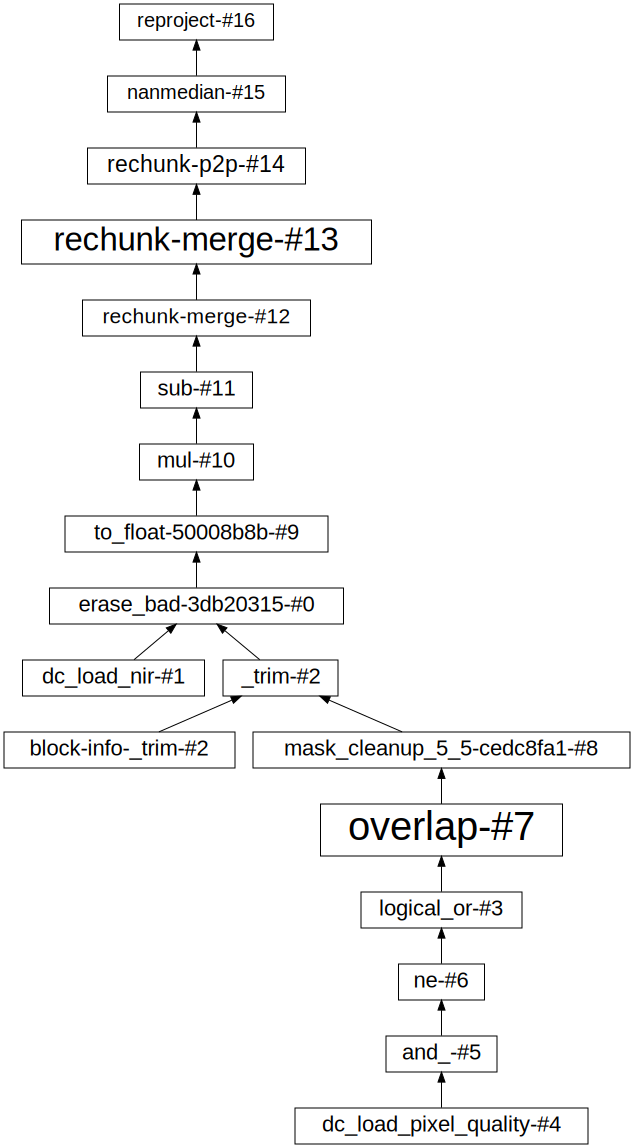

In [24]:
new_data.nir.data.dask.visualize()

In [26]:
print(nir_data)

<xarray.DataArray 'nir' (y: 8328, x: 9539)> Size: 318MB
dask.array<reproject, shape=(8328, 9539), dtype=float32, chunksize=(304, 304), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 67kB -2.456e+06 -2.456e+06 ... -3.289e+06
  * x            (x) float64 76kB 2.409e+06 2.409e+06 ... 3.363e+06 3.363e+06
    spatial_ref  int32 4B 6933


In [ ]:
with ProgressBar():
    nir_data_1 = nir_data.compute()

/opt/venv/lib/python3.10/site-packages/distributed/client.py:3361: UserWarning: Sending large graph of size 74.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
ds <- ndvi$wx$to_xarray(region=geom, scale=
                            if_else(n_features<10, 250,
                                    if_else(n_features<50, 500,
                                            if_else(n_features<100, 5000,
                                                    if_else(n_features<1e+3, 10000,
                                                            if_else(n_features<5e+3, 20000, 50000))))))

In [ ]:
print(lazy_data)

In [ ]:
image_url = lazy_data.red.data

In [ ]:
m.add_layer(image_url)

In [ ]:
m

In [ ]:
from deafrica_tools.spatial import add_geobox

In [ ]:
lazy_data=add_geobox(lazy_data)

In [ ]:
lazy_data_reprojected = lazy_data.odc.reproject(how=lazy_data.odc.crs, resolution=50)

In [ ]:
print(lazy_data_reprojected)

In [ ]:
lazy_data_reprojected = calculate_indices(lazy_data_reprojected, index="NDVI", satellite_mission="ls", drop=True)

In [ ]:
print(lazy_data_reprojected)

In [ ]:
lazy_data_NDVI = lazy_data_reprojected.NDVI.compute()

In [ ]:
print(lazy_data_ndvi)

In [ ]:
# band_diff = lazy_data.blue - lazy_data.red
# band_sum = lazy_data.green + lazy_data.red

# lazy_data['ndvi'] = band_diff / band_sum

Doing this adds the new `ndvi` Dask array to the `lazy_data` dataset:

In [ ]:
# print(lazy_data)

In [ ]:
from deafrica_tools.spatial import add_geobox

In [ ]:
lazy_data_ndvi=add_geobox(lazy_data_ndvi)

In [ ]:
lazy_data_reprojected = lazy_data_ndvi.odc.reproject(how=lazy_data_ndvi.odc.crs, resolution=50)

In [ ]:
print(lazy_data_reprojected)

In [ ]:
plot = lazy_data_reprojected.compute()

In [ ]:
plot.NDVI.plot()

In [ ]:
for chunk in lazy_data.ndvi.:
    chunk_result = chunk.compute()
    chunk_result.plot()
    

In [ ]:
# print(lazy_data.isel(time=0).ndvi.values())

In [ ]:
# pip install hvplot

In [ ]:
import dask
import hvplot.dask

In [ ]:

df_dask = dask.dataframe.from_pandas(df, npartitions=2)
df_dask.hvplot.scatter(x='bill_length_mm', y='bill_depth_mm', by='species')

In [ ]:
agg =  ds.Canvas(plot_width=100, plot_height=100).raster(lazy_data_dask, 
                  downsample_method='mean')
img = tf.shade(agg)

In [ ]:
lazy_data.isel(time=1).ndvi.plot()

In [ ]:
# pip install datashader

In [ ]:
import datashader as ds
import datashader.transfer_functions as tf

In [ ]:
tf.shade(lazy_data.ndvi)

In [ ]:
lazy_data_dask = lazy_data.isel(time=0).ndvi.to_dask_dataframe(["y", "x"])

In [ ]:
lazy_data_dask

In [ ]:
agg =  ds.Canvas(plot_width=800, plot_height=800).raster(lazy_data_dask, 
                  downsample_method='mean')
img = tf.shade(agg, cmap=cmap)

In [ ]:
tf.Images(ds.Canvas().points(lazy_data_dask,'x','y'))

In [ ]:
# Create a canvas for plotting
canvas = ds.Canvas(plot_width=800, plot_height=400)

# Aggregate data (e.g., taking the mean value)
agg = canvas.points(lazy_data.ndvi, 'y', 'x', agg=lazy_data.ndvi.mean())

# Create an image using Datashader
img = tf.shade(agg, cmap='viridis')

# Show the image
img.to_pil().show()

In [ ]:
# Aggregate the data
agg = canvas.points(lazy_data.ndvi, 'x', 'y')

In [ ]:
%time tf.shade(ds.Canvas().points(lazy_data.ndvi,'x','y'))

In [ ]:
tf.Images(lazy_data.isel(time=0).ndvi).to_pil().show()

In [ ]:
ldata = lazy_data[x=[:6000], y=[:6000]]

In [ ]:
ldata.isel(time=1).red.plot()

In [ ]:
# from datacube.utils.cog import write_cog
# import os
# import subprocess

# data = f"data/"
# if not os.path.exists(data):
#     os.makedirs(data)

# for i in range(1 , 30):
#     var_start = (i - 1) * 3000
#     var_end =  i * 3000
#     band = lazy_month['ndvi'][1, var_start:var_end, var_start:var_end].compute()
#     write_cog(band,fname=f"{data}/band_{i}.tif", overwrite=True)
    
# out_merge = f"merge/merge.tiff"
# if os.path.exists(out_merge): 
#     subprocess.run(f"rm {out_merge}", shell=True)
# if not os.path.exists("merge/"):
#     os.makedirs("merge/")
# merge_cmd = f"gdal_merge.py -o {out_merge} -co COMPRESS=Deflate -ot Byte data/*.tif -init 255 -a_nodata 255"
# subprocess.run(merge_cmd, shell=True)
# subprocess.run(f"rm -rf {out_mosaic}", shell=True)

In [ ]:
# import rioxarray

In [ ]:
# ds = rioxarray.open_rasterio('merge/merge.tiff')

In [ ]:
# ds.plot(robust=True)